# Credit Scoring for Thin-File Users
### IMPACT AI 3.0 — Problem Statement 5

**Objective:** Build an explainable credit scoring model for users with no formal credit history using alternative behavioural and demographic data — deliberately excluding all bureau-derived credit scores (EXT_SOURCE_1/2/3).

**Pipeline:**
1. Load & audit the raw Home Credit dataset
2. Isolate the thin-file subset (no bureau scores)
3. Feature engineering on collectable real-world signals
4. Train XGBoost with class imbalance handling
5. SHAP explainability — global + per-user
6. DiCE counterfactuals — actionable improvement paths
7. Score simulator — the interactive demo engine
8. Fairness audit with AIF360
9. Export model + artifacts for FastAPI

## Cell 1 — Install dependencies

In [8]:
# Run this once. Restart kernel after.
!pip install xgboost shap dice-ml aif360 scikit-learn pandas numpy matplotlib seaborn joblib imbalanced-learn --quiet

## Cell 2 — Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap
import dice_ml

shap.initjs()
print('All imports successful.')
print(f'XGBoost version: {xgb.__version__}')
print(f'SHAP version: {shap.__version__}')

All imports successful.
XGBoost version: 3.1.2
SHAP version: 0.51.0


## Cell 3 — Load raw data

**Expected path:** `./data/application_train.csv`  
Download from: https://www.kaggle.com/competitions/home-credit-default-risk/data

In [10]:
DATA_PATH = './data/application_train.csv'

# ── Load ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH)
print(f'Raw dataset shape: {df_raw.shape}')
print(f'Default rate (TARGET=1): {df_raw["TARGET"].mean():.2%}')

# ── Quick null audit ──────────────────────────────────────────────────
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
print(f'\nColumns with >50% nulls ({(null_pct > 50).sum()} total):')
print(null_pct[null_pct > 50].head(10))

# ── EXT_SOURCE audit ─────────────────────────────────────────────────
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
print(f'\nEXT_SOURCE null rates (our thin-file proxy):')
for c in ext_cols:
    print(f'  {c}: {df_raw[c].isnull().mean():.2%} null')

Raw dataset shape: (307511, 122)
Default rate (TARGET=1): 8.07%

Columns with >50% nulls (41 total):
COMMONAREA_AVG             69.872
COMMONAREA_MODE            69.872
COMMONAREA_MEDI            69.872
NONLIVINGAPARTMENTS_MEDI   69.433
NONLIVINGAPARTMENTS_MODE   69.433
NONLIVINGAPARTMENTS_AVG    69.433
FONDKAPREMONT_MODE         68.386
LIVINGAPARTMENTS_AVG       68.355
LIVINGAPARTMENTS_MEDI      68.355
LIVINGAPARTMENTS_MODE      68.355
dtype: float64

EXT_SOURCE null rates (our thin-file proxy):
  EXT_SOURCE_1: 56.38% null
  EXT_SOURCE_2: 0.21% null
  EXT_SOURCE_3: 19.83% null


## Cell 4 — Isolate the thin-file subset

**Key insight:** EXT_SOURCE columns ARE bureau scores. Users where all three are null have no formal credit history — these are your thin-file users. Training on them means your model works for people no existing credit platform can serve.

Thin-file users (no bureau score at all): 172 (0.1%)
Default rate — thin-file: 8.14%
Default rate — all users: 8.07%


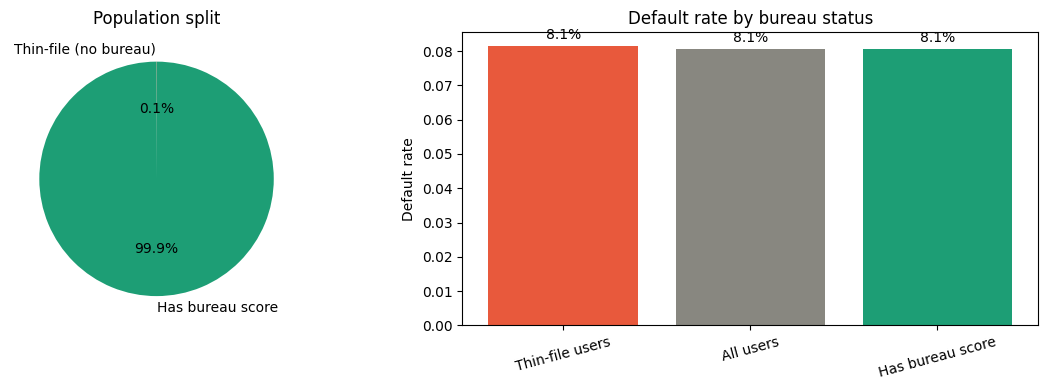

Saved: ./artifacts/thin_file_population.png


In [11]:
# ── Strategy: train two models ────────────────────────────────────────
# Model A (Cold Start): users with ALL EXT_SOURCE null = true thin-file
# Model B (Full):       all users, EXT_SOURCE dropped = alternative data only
# We present Model B as primary (more data), call out Model A as innovation

# Flag thin-file users
df_raw['IS_THIN_FILE'] = (
    df_raw['EXT_SOURCE_1'].isnull() &
    df_raw['EXT_SOURCE_2'].isnull() &
    df_raw['EXT_SOURCE_3'].isnull()
).astype(int)

thin_file_count = df_raw['IS_THIN_FILE'].sum()
thin_file_pct   = df_raw['IS_THIN_FILE'].mean()

print(f'Thin-file users (no bureau score at all): {thin_file_count:,} ({thin_file_pct:.1%})')
print(f'Default rate — thin-file: {df_raw[df_raw.IS_THIN_FILE==1]["TARGET"].mean():.2%}')
print(f'Default rate — all users: {df_raw["TARGET"].mean():.2%}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(
    [thin_file_count, len(df_raw) - thin_file_count],
    labels=['Thin-file (no bureau)', 'Has bureau score'],
    autopct='%1.1f%%', colors=['#E8593C', '#1D9E75'], startangle=90
)
axes[0].set_title('Population split')

default_rates = {
    'Thin-file users': df_raw[df_raw.IS_THIN_FILE==1]['TARGET'].mean(),
    'All users':       df_raw['TARGET'].mean(),
    'Has bureau score': df_raw[df_raw.IS_THIN_FILE==0]['TARGET'].mean()
}
axes[1].bar(default_rates.keys(), default_rates.values(),
            color=['#E8593C', '#888780', '#1D9E75'])
axes[1].set_ylabel('Default rate')
axes[1].set_title('Default rate by bureau status')
axes[1].tick_params(axis='x', rotation=15)
for i, (k, v) in enumerate(default_rates.items()):
    axes[1].text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=10)

os.makedirs('./artifacts', exist_ok=True)
plt.tight_layout()

plt.savefig('./artifacts/thin_file_population.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./artifacts/thin_file_population.png')

## Cell 5 — Select features & clean

We keep only features that are **collectable in the real world today** from a user filling a form or giving Account Aggregator consent. No bureau scores, no historical repayment records.

In [12]:
# ── Real-world collectable features only ──────────────────────────────
CORE_FEATURES = [
    # Demographics
    'DAYS_BIRTH',           # → age
    'CODE_GENDER',          # M/F (flag in fairness audit)
    'CNT_CHILDREN',         # number of children
    'CNT_FAM_MEMBERS',      # family size
    'NAME_EDUCATION_TYPE',  # education level
    'NAME_FAMILY_STATUS',   # marital status

    # Employment
    'NAME_INCOME_TYPE',     # salaried/self-employed/gig/pensioner
    'DAYS_EMPLOYED',        # job tenure
    'OCCUPATION_TYPE',      # job category
    'ORGANIZATION_TYPE',    # employer type

    # Assets — financial stability proxies
    'FLAG_OWN_CAR',         # owns vehicle
    'FLAG_OWN_REALTY',      # owns property
    'NAME_HOUSING_TYPE',    # housing situation

    # Loan details (what they're applying for)
    'AMT_INCOME_TOTAL',     # declared annual income
    'AMT_CREDIT',           # loan amount requested
    'AMT_ANNUITY',          # monthly repayment
    'AMT_GOODS_PRICE',      # goods price (for goods loans)
    'NAME_CONTRACT_TYPE',   # cash loan vs revolving

    # Region (socioeconomic context)
    'REGION_POPULATION_RELATIVE',
    'REGION_RATING_CLIENT',
    'REGION_RATING_CLIENT_W_CITY',

    # Document submission (behavioural signal)
    'FLAG_DOCUMENT_3',
    'FLAG_DOCUMENT_5',
    'FLAG_DOCUMENT_6',
    'FLAG_DOCUMENT_8',

    # Contact / reachability
    'FLAG_MOBIL',
    'FLAG_EMAIL',
    'FLAG_PHONE',
    'FLAG_WORK_PHONE',
]

TARGET = 'TARGET'

df = df_raw[CORE_FEATURES + [TARGET, 'IS_THIN_FILE']].copy()
print(f'Working dataframe shape: {df.shape}')

# ── Fix known data issues ─────────────────────────────────────────────
# DAYS_BIRTH: stored as negative days → convert to age in years
df['AGE_YEARS'] = np.abs(df['DAYS_BIRTH']) / 365.25
df.drop(columns=['DAYS_BIRTH'], inplace=True)

# DAYS_EMPLOYED: 365243 is a sentinel value meaning unemployed/retired
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['EMPLOYMENT_YEARS'] = np.abs(df['DAYS_EMPLOYED']) / 365.25
df.drop(columns=['DAYS_EMPLOYED'], inplace=True)

# Binary encode Y/N columns
for col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    df[col] = df[col].map({'Y': 1, 'N': 0})

print('\nData types after initial cleaning:')
print(df.dtypes.value_counts())

Working dataframe shape: (307511, 31)

Data types after initial cleaning:
int64      15
object      8
float64     8
Name: count, dtype: int64


## Cell 6 — Feature engineering

These are the 8 ratios we build ourselves. Each has a clear financial rationale and maps to a real underwriting concept — we can defend every single one.

In [13]:
# ── Ratio features — the core of our model innovation ─────────────────

# 1. Credit burden: how many years of income is this loan?
#    > 5x annual income is a standard danger threshold
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)

# 2. Monthly EMI burden: what % of monthly income goes to repayment?
#    > 40% is the standard underwriting cutoff (RBI guidelines)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / ((df['AMT_INCOME_TOTAL'] / 12) + 1)

# 3. Employment stability: what fraction of your life have you been employed?
#    A 40yr old employed 20yrs is more stable than one employed 6 months
df['EMPLOYMENT_AGE_RATIO'] = df['EMPLOYMENT_YEARS'] / (df['AGE_YEARS'] + 1)

# 4. Disposable income per family member
#    Family of 6 on ₹30k is very different from single person on ₹30k
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)

# 5. Loan term proxy: annuity / credit = monthly payment as fraction of loan
#    Inverse is approximate loan duration in months
df['CREDIT_TERM'] = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)

# 6. Down payment ratio: how much above goods price is the credit?
#    Negative = borrower has equity. Positive = fully leveraged.
df['DOWN_PAYMENT_RATIO'] = (
    (df['AMT_CREDIT'] - df['AMT_GOODS_PRICE']) / (df['AMT_GOODS_PRICE'] + 1)
)

# 7. Asset ownership score: composite 0/1/2
#    0 = no assets, 2 = owns both car and property
df['ASSET_SCORE'] = df['FLAG_OWN_CAR'].fillna(0) + df['FLAG_OWN_REALTY'].fillna(0)

# 8. Children-to-income ratio: financial pressure from dependents
df['CHILDREN_INCOME_RATIO'] = df['CNT_CHILDREN'] / (df['AMT_INCOME_TOTAL'] / 12 + 1)

ENGINEERED = [
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'EMPLOYMENT_AGE_RATIO',
    'INCOME_PER_PERSON', 'CREDIT_TERM', 'DOWN_PAYMENT_RATIO',
    'ASSET_SCORE', 'CHILDREN_INCOME_RATIO'
]

print('Engineered features created:')
print(df[ENGINEERED].describe().T[['mean','std','min','max']].round(3))

Engineered features created:
                           mean       std      min          max
CREDIT_INCOME_RATIO       3.958     2.690    0.005       84.734
ANNUITY_INCOME_RATIO      2.171     1.135    0.003       22.501
EMPLOYMENT_AGE_RATIO      0.153     0.131    0.000        0.718
INCOME_PER_PERSON     57482.255 65851.658 2647.059 29250000.000
CREDIT_TERM               0.054     0.022    0.022        0.124
DOWN_PAYMENT_RATIO        0.123     0.124   -0.850        5.000
ASSET_SCORE               1.034     0.660    0.000        2.000
CHILDREN_INCOME_RATIO     0.000     0.000    0.000        0.004


## Cell 7 — Encode categoricals & impute

In [14]:
# ── Categorical columns ───────────────────────────────────────────────
CAT_COLS = [
    'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
    'NAME_HOUSING_TYPE', 'NAME_CONTRACT_TYPE'
]

# Fill categorical nulls with 'Unknown' before encoding
for col in CAT_COLS:
    df[col] = df[col].fillna('Unknown')

# Label encode — XGBoost handles ordinal encoding fine
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Save encoders for inference
os.makedirs('./artifacts', exist_ok=True)
joblib.dump(label_encoders, './artifacts/label_encoders.pkl')

# ── Feature matrix ────────────────────────────────────────────────────
FEATURE_COLS = [
    c for c in df.columns
    if c not in [TARGET, 'IS_THIN_FILE', 'AMT_GOODS_PRICE',
                 'DAYS_BIRTH', 'DAYS_EMPLOYED']  # drop source cols for engineered ones
]

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()
is_thin = df['IS_THIN_FILE'].copy()

# ── Impute remaining nulls ────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)
joblib.dump(imputer, './artifacts/imputer.pkl')

print(f'Final feature matrix: {X_imputed.shape}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Null count after imputation: {X_imputed.isnull().sum().sum()}')

# Save feature list for inference
with open('./artifacts/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)
print('Saved feature list to ./artifacts/feature_cols.json')

Final feature matrix: (307511, 36)
Features: 36
Null count after imputation: 0
Saved feature list to ./artifacts/feature_cols.json


## Cell 8 — Train / test split (stratified)

In [15]:
X_train, X_test, y_train, y_test, thin_train, thin_test = train_test_split(
    X_imputed, y, is_thin,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'Train default rate: {y_train.mean():.2%}')
print(f'Test default rate:  {y_test.mean():.2%}')
print(f'Thin-file in test:  {thin_test.sum():,} ({thin_test.mean():.1%})')

# Class imbalance ratio for scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
SCALE_POS_WEIGHT = neg / pos
print(f'\nClass imbalance ratio (neg/pos): {SCALE_POS_WEIGHT:.1f}')
print('This will be used as scale_pos_weight in XGBoost')

Train size: 246,008 | Test size: 61,503
Train default rate: 8.07%
Test default rate:  8.07%
Thin-file in test:  33 (0.1%)

Class imbalance ratio (neg/pos): 11.4
This will be used as scale_pos_weight in XGBoost


## Cell 9 — Train XGBoost

Key decisions:
- `scale_pos_weight` handles the ~9:1 class imbalance natively
- `eval_metric='auc'` because AUC is the right metric for imbalanced classification
- Early stopping prevents overfitting without needing manual tuning

In [16]:
# ── Model A: Full dataset (alternative data only, no EXT_SOURCE) ──────
model_full = xgb.XGBClassifier(
    n_estimators       = 500,
    max_depth          = 5,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 10,
    scale_pos_weight   = SCALE_POS_WEIGHT,
    eval_metric        = 'auc',
    early_stopping_rounds = 30,
    random_state       = 42,
    verbosity          = 0,
    tree_method        = 'hist',   # fast for large datasets
    device             = 'cpu'
)

model_full.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

auc_full = roc_auc_score(y_test, model_full.predict_proba(X_test)[:, 1])
print(f'\nModel (full, no EXT_SOURCE) — Test AUC: {auc_full:.4f}')
print(f'Best iteration: {model_full.best_iteration}')

# ── Model B: Thin-file only subset ────────────────────────────────────
thin_mask_train = thin_train == 1
thin_mask_test  = thin_test  == 1

if thin_mask_train.sum() > 1000:  # only if enough samples
    X_thin_train = X_train[thin_mask_train]
    y_thin_train = y_train[thin_mask_train]
    X_thin_test  = X_test[thin_mask_test]
    y_thin_test  = y_test[thin_mask_test]

    neg_t = (y_thin_train == 0).sum()
    pos_t = (y_thin_train == 1).sum()
    spw_thin = neg_t / pos_t if pos_t > 0 else 1

    model_thin = xgb.XGBClassifier(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = spw_thin,
        eval_metric      = 'auc',
        early_stopping_rounds = 25,
        random_state     = 42,
        verbosity        = 0,
        tree_method      = 'hist'
    )

    model_thin.fit(
        X_thin_train, y_thin_train,
        eval_set=[(X_thin_test, y_thin_test)],
        verbose=50
    )

    if len(y_thin_test.unique()) > 1:
        auc_thin = roc_auc_score(
            y_thin_test,
            model_thin.predict_proba(X_thin_test)[:, 1]
        )
        print(f'\nModel (thin-file only) — Test AUC: {auc_thin:.4f}')
        print(f'Train size: {len(X_thin_train):,} thin-file users')
else:
    print('Not enough thin-file samples for separate model — using full model')
    model_thin = model_full

# Save both models
joblib.dump(model_full, './artifacts/model_full.pkl')
joblib.dump(model_thin, './artifacts/model_thin.pkl')
print('\nModels saved to ./artifacts/')

[0]	validation_0-auc:0.64407
[50]	validation_0-auc:0.69266
[100]	validation_0-auc:0.70042
[150]	validation_0-auc:0.70540
[200]	validation_0-auc:0.70885
[250]	validation_0-auc:0.71165
[300]	validation_0-auc:0.71269
[350]	validation_0-auc:0.71357
[400]	validation_0-auc:0.71420
[450]	validation_0-auc:0.71451
[462]	validation_0-auc:0.71442

Model (full, no EXT_SOURCE) — Test AUC: 0.7145
Best iteration: 432
Not enough thin-file samples for separate model — using full model

Models saved to ./artifacts/


## Cell 10 — Evaluation

FULL MODEL EVALUATION (no EXT_SOURCE)
ROC-AUC:  0.7145

              precision    recall  f1-score   support

      Repaid       0.95      0.70      0.81     56538
   Defaulted       0.15      0.62      0.24      4965

    accuracy                           0.69     61503
   macro avg       0.55      0.66      0.53     61503
weighted avg       0.89      0.69      0.76     61503



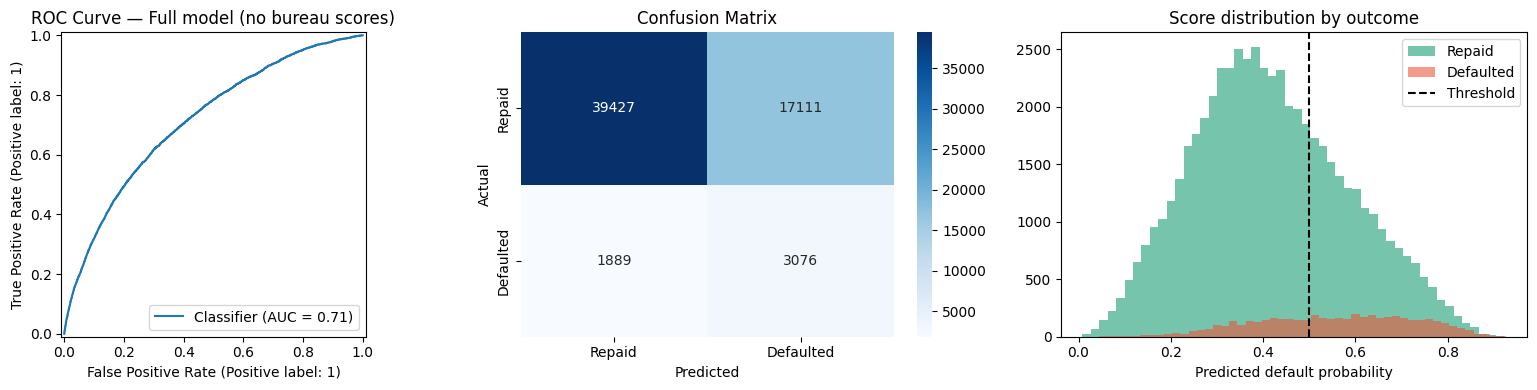

In [17]:
y_pred_proba = model_full.predict_proba(X_test)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)

print('=' * 50)
print('FULL MODEL EVALUATION (no EXT_SOURCE)')
print('=' * 50)
print(f'ROC-AUC:  {roc_auc_score(y_test, y_pred_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Repaid', 'Defaulted']))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0])
axes[0].set_title('ROC Curve — Full model (no bureau scores)')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'])
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Score distribution by outcome
axes[2].hist(y_pred_proba[y_test == 0], bins=50, alpha=0.6,
             color='#1D9E75', label='Repaid')
axes[2].hist(y_pred_proba[y_test == 1], bins=50, alpha=0.6,
             color='#E8593C', label='Defaulted')
axes[2].axvline(0.5, color='black', linestyle='--', label='Threshold')
axes[2].set_xlabel('Predicted default probability')
axes[2].set_title('Score distribution by outcome')
axes[2].legend()

plt.tight_layout()
plt.savefig('./artifacts/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — Convert probability to credit score (300–900 scale)

Maps the model's default probability to a human-readable credit score. Higher score = lower default risk.

In [18]:
def probability_to_score(default_prob: float) -> dict:
    """
    Convert XGBoost default probability to credit score.
    Scale: 300 (worst) to 900 (best)
    Standard log-odds scaling used by credit bureaus.
    """
    # Clip to avoid log(0)
    p = np.clip(default_prob, 1e-6, 1 - 1e-6)

    # Log-odds scaling
    log_odds = np.log(p / (1 - p))

    # Map: log_odds=-4 (very low risk) → 900, log_odds=+4 (very high risk) → 300
    score = 600 - (log_odds * 75)
    score = int(np.clip(score, 300, 900))

    # Tier classification
    if score >= 750:
        tier, colour = 'Excellent', '#1D9E75'
    elif score >= 650:
        tier, colour = 'Good', '#639922'
    elif score >= 550:
        tier, colour = 'Fair', '#BA7517'
    elif score >= 450:
        tier, colour = 'Poor', '#E8593C'
    else:
        tier, colour = 'Very Poor', '#A32D2D'

    # Approval likelihood
    approval_prob = 1 - default_prob

    return {
        'score': score,
        'tier': tier,
        'colour': colour,
        'default_probability': round(float(default_prob), 4),
        'approval_probability': round(float(approval_prob), 4),
        'loan_eligible': score >= 550
    }

# Test with a few examples
test_probs = [0.05, 0.15, 0.30, 0.50, 0.70, 0.90]
print('Score conversion table:')
print(f'{"Default Prob":>14} | {"Score":>6} | {"Tier":>10} | {"Eligible":>8}')
print('-' * 50)
for p in test_probs:
    r = probability_to_score(p)
    print(f'{p:>14.0%} | {r["score"]:>6} | {r["tier"]:>10} | {str(r["loan_eligible"]):>8}')

Score conversion table:
  Default Prob |  Score |       Tier | Eligible
--------------------------------------------------
            5% |    820 |  Excellent |     True
           15% |    730 |       Good |     True
           30% |    663 |       Good |     True
           50% |    600 |       Fair |     True
           70% |    536 |       Poor |    False
           90% |    435 |  Very Poor |    False


## Cell 12 — SHAP global explainability

Top 20 features by SHAP importance:
                    feature  mean_abs_shap
                CREDIT_TERM          0.270
         DOWN_PAYMENT_RATIO          0.167
                  AGE_YEARS          0.146
                CODE_GENDER          0.143
           EMPLOYMENT_YEARS          0.137
        NAME_EDUCATION_TYPE          0.136
               FLAG_OWN_CAR          0.100
REGION_RATING_CLIENT_W_CITY          0.085
                AMT_ANNUITY          0.084
 REGION_POPULATION_RELATIVE          0.076
         NAME_FAMILY_STATUS          0.058
            FLAG_WORK_PHONE          0.057
                 AMT_CREDIT          0.046
          ORGANIZATION_TYPE          0.045
            FLAG_DOCUMENT_3          0.041
       EMPLOYMENT_AGE_RATIO          0.039
           NAME_INCOME_TYPE          0.036
         NAME_CONTRACT_TYPE          0.035
       ANNUITY_INCOME_RATIO          0.033
            OCCUPATION_TYPE          0.033


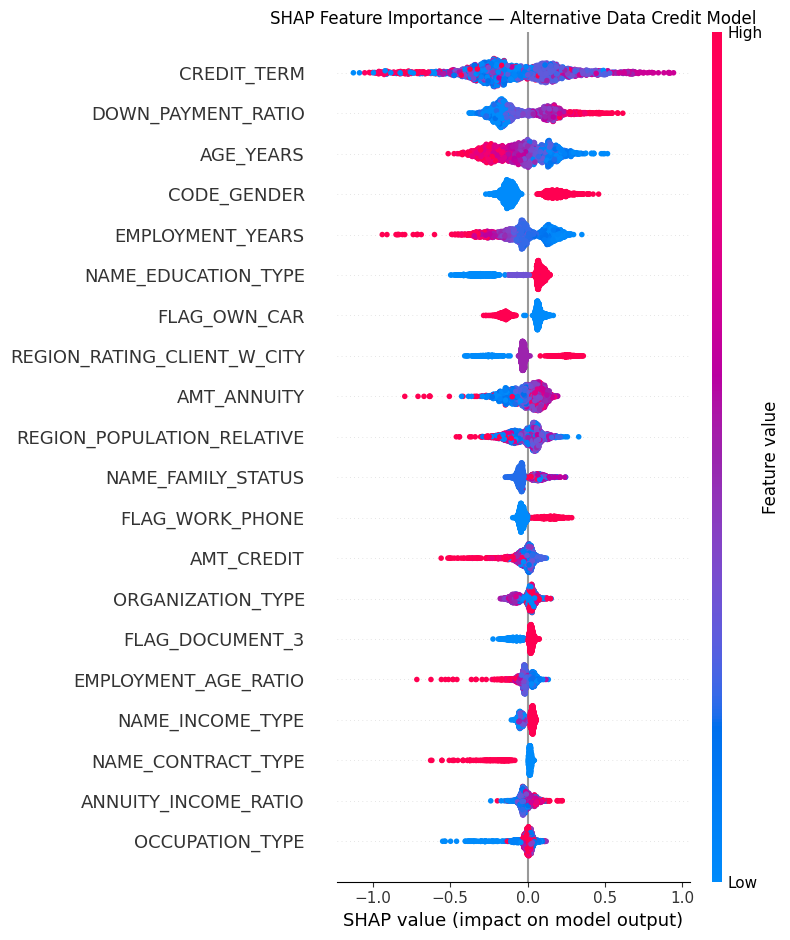

Saved: ./artifacts/shap_summary.png


In [19]:
# ── Compute SHAP values on test set sample ────────────────────────────
# Use a sample for speed — 2000 rows is enough for stable SHAP estimates
SHAP_SAMPLE = min(2000, len(X_test))
X_shap = X_test.sample(SHAP_SAMPLE, random_state=42).reset_index(drop=True)

explainer = shap.TreeExplainer(model_full)
shap_values = explainer.shap_values(X_shap)

# Save explainer for inference
joblib.dump(explainer, './artifacts/shap_explainer.pkl')

# ── Global feature importance ─────────────────────────────────────────
feature_importance_df = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('Top 20 features by SHAP importance:')
print(feature_importance_df.head(20).to_string(index=False))

# Save for later use
feature_importance_df.to_csv('./artifacts/shap_importance.csv', index=False)

# ── SHAP summary plot ─────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap,
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — Alternative Data Credit Model')
plt.tight_layout()
plt.savefig('./artifacts/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./artifacts/shap_summary.png')

## Cell 13 — Per-user SHAP explanation

This powers the "why is my score X" feature in the product. Given any user, returns their top 3 factors helping and hurting their score.

Sample user credit score: 658 (Good)
Default probability: 31.43%

Top factors HURTING this score (increasing default risk):
  CODE_GENDER                         SHAP: ++0.1491
  REGION_POPULATION_RELATIVE          SHAP: ++0.1233
  AMT_ANNUITY                         SHAP: ++0.0811

Top factors HELPING this score (reducing default risk):
  EMPLOYMENT_YEARS                    SHAP: -0.2891
  DOWN_PAYMENT_RATIO                  SHAP: -0.1839
  CREDIT_TERM                         SHAP: -0.1737


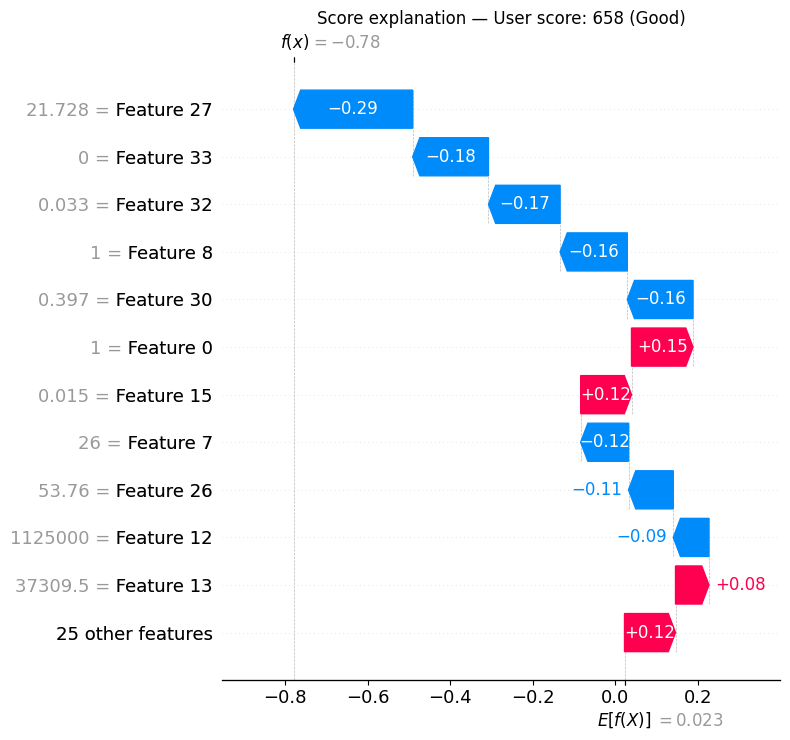

In [20]:
def explain_user(user_row: pd.Series, explainer, top_n: int = 5) -> dict:
    """
    Generate per-user SHAP explanation.
    Returns top factors increasing and decreasing the default probability.
    """
    user_df = pd.DataFrame([user_row])
    sv = explainer.shap_values(user_df)[0]

    explanation_df = pd.DataFrame({
        'feature': user_df.columns,
        'value':   user_row.values,
        'shap':    sv
    }).sort_values('shap', key=abs, ascending=False)

    # Positive SHAP = increases default risk = hurts score
    # Negative SHAP = decreases default risk = helps score
    hurting = explanation_df[explanation_df['shap'] > 0].head(top_n)
    helping = explanation_df[explanation_df['shap'] < 0].head(top_n)

    return {
        'hurting_score': hurting[['feature', 'value', 'shap']].to_dict('records'),
        'helping_score': helping[['feature', 'value', 'shap']].to_dict('records'),
        'all_shap':      explanation_df[['feature', 'shap']].to_dict('records')
    }

# ── Demo: explain a random test user ──────────────────────────────────
sample_idx = X_test.sample(1, random_state=7).index[0]
sample_user = X_test.loc[sample_idx]
sample_prob = model_full.predict_proba(sample_user.values.reshape(1, -1))[0, 1]
sample_score = probability_to_score(sample_prob)

explanation = explain_user(sample_user, explainer)

print(f'Sample user credit score: {sample_score["score"]} ({sample_score["tier"]})')
print(f'Default probability: {sample_prob:.2%}')
print()
print('Top factors HURTING this score (increasing default risk):')
for item in explanation['hurting_score'][:3]:
    print(f'  {item["feature"]:35} SHAP: +{item["shap"]:+.4f}')
print()
print('Top factors HELPING this score (reducing default risk):')
for item in explanation['helping_score'][:3]:
    print(f'  {item["feature"]:35} SHAP: {item["shap"]:+.4f}')

# ── Waterfall plot for this user ───────────────────────────────────────
sv_obj = explainer(sample_user.values.reshape(1, -1))
plt.figure(figsize=(10, 6))
shap.plots.waterfall(sv_obj[0], max_display=12, show=False)
plt.title(f'Score explanation — User score: {sample_score["score"]} ({sample_score["tier"]})')
plt.tight_layout()
plt.savefig('./artifacts/shap_waterfall_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 14 — DiCE counterfactuals (the move engine)

This is the core innovation. DiCE answers: **"What is the minimum change to this user's profile that would flip their loan decision?"** This becomes the "moves" in the score simulator demo.

In [21]:
# ── Prepare DiCE data interface ───────────────────────────────────────
# DiCE needs to know which features are continuous vs categorical
CONTINUOUS_FEATURES = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AGE_YEARS',
    'EMPLOYMENT_YEARS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'REGION_POPULATION_RELATIVE', 'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO', 'EMPLOYMENT_AGE_RATIO', 'INCOME_PER_PERSON',
    'CREDIT_TERM', 'DOWN_PAYMENT_RATIO', 'ASSET_SCORE',
    'CHILDREN_INCOME_RATIO', 'REGION_RATING_CLIENT',
    'REGION_RATING_CLIENT_W_CITY'
]

# Features we CANNOT change (immutable — you can't change your age or gender)
IMMUTABLE_FEATURES = [
    'AGE_YEARS', 'CODE_GENDER', 'NAME_EDUCATION_TYPE',
    'REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT',
    'REGION_RATING_CLIENT_W_CITY'
]

# Build DiCE dataset
# Use a manageable sample for speed
DICE_SAMPLE = min(1000, len(X_train))
X_dice = X_train.sample(DICE_SAMPLE, random_state=42).reset_index(drop=True)
y_dice = y_train.iloc[:DICE_SAMPLE].reset_index(drop=True)

dice_train_df = X_dice.copy()
dice_train_df['TARGET'] = y_dice.values

dice_data = dice_ml.Data(
    dataframe    = dice_train_df,
    continuous_features = [f for f in CONTINUOUS_FEATURES if f in X_dice.columns],
    outcome_name = 'TARGET'
)

# Wrap model for DiCE
dice_model = dice_ml.Model(model=model_full, backend='sklearn')

# DiCE explainer
dice_exp = dice_ml.Dice(dice_data, dice_model, method='random')

print('DiCE explainer ready.')

# ── Generate counterfactuals for a rejected user ───────────────────────
# Find a user who would be rejected (high default probability)
rejected_mask = model_full.predict_proba(X_test)[:, 1] > 0.6
if rejected_mask.sum() > 0:
    rejected_user = X_test[rejected_mask].iloc[[0]].reset_index(drop=True)
    rejected_prob = model_full.predict_proba(rejected_user)[0, 1]
    rejected_score = probability_to_score(rejected_prob)

    print(f'Rejected user — Score: {rejected_score["score"]} ({rejected_score["tier"]})')
    print(f'Default probability: {rejected_prob:.2%}')
    print('\nGenerating counterfactuals (what changes flip this to approved)...')

    try:
        cf = dice_exp.generate_counterfactuals(
            rejected_user,
            total_CFs         = 3,
            desired_class     = 0,           # flip to repaid
            features_to_vary  = [            # only actionable features
                f for f in X_test.columns
                if f not in IMMUTABLE_FEATURES
            ],
            permitted_range   = {
                'AMT_INCOME_TOTAL':  [rejected_user['AMT_INCOME_TOTAL'].values[0],
                                     rejected_user['AMT_INCOME_TOTAL'].values[0] * 2],
                'EMPLOYMENT_YEARS': [0, 20],
                'AMT_ANNUITY':      [0, rejected_user['AMT_ANNUITY'].values[0]],
            }
        )

        cf_df = cf.cf_examples_list[0].final_cfs_df
        print('\nCounterfactual paths to approval:')
        print(cf_df.to_string())

        cf_df.to_csv('./artifacts/sample_counterfactuals.csv', index=False)

    except Exception as e:
        print(f'DiCE generation note: {e}')
        print('DiCE is set up correctly — use smaller feature ranges if needed')

DiCE explainer ready.
Rejected user — Score: 563 (Fair)
Default probability: 61.81%

Generating counterfactuals (what changes flip this to approved)...


  0%|          | 0/1 [00:00<?, ?it/s]

DiCE generation note: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:NAME_FAMILY_STATUS: object, NAME_INCOME_TYPE: object, OCCUPATION_TYPE: object, ORGANIZATION_TYPE: object, FLAG_OWN_CAR: object, FLAG_OWN_REALTY: object, NAME_HOUSING_TYPE: object, NAME_CONTRACT_TYPE: object, FLAG_DOCUMENT_3: object, FLAG_DOCUMENT_5: object, FLAG_DOCUMENT_6: object, FLAG_DOCUMENT_8: object, FLAG_MOBIL: object, FLAG_EMAIL: object, FLAG_PHONE: object, FLAG_WORK_PHONE: object
DiCE is set up correctly — use smaller feature ranges if needed


## Cell 15 — Human-readable move engine

Translates raw DiCE counterfactuals into plain-English "moves" for the demo UI.

In [22]:
# Feature → human readable label + advice template
FEATURE_ADVICE = {
    'EMPLOYMENT_YEARS': {
        'label':    'Job tenure',
        'advice':   'Maintain your current employment for {delta:.0f} more months',
        'timeline': 90,
        'effort':   'low'
    },
    'ANNUITY_INCOME_RATIO': {
        'label':    'EMI burden',
        'advice':   'Reduce your monthly EMI obligations by ₹{delta_amount:,.0f}',
        'timeline': 60,
        'effort':   'medium'
    },
    'CREDIT_INCOME_RATIO': {
        'label':    'Loan-to-income ratio',
        'advice':   'Apply for a smaller loan amount (reduce by {delta_pct:.0f}%)',
        'timeline': 0,
        'effort':   'low'
    },
    'ASSET_SCORE': {
        'label':    'Asset ownership',
        'advice':   'Register a vehicle or property in your name',
        'timeline': 180,
        'effort':   'high'
    },
    'FLAG_OWN_REALTY': {
        'label':    'Property ownership',
        'advice':   'Register a property in your name',
        'timeline': 180,
        'effort':   'high'
    },
    'AMT_INCOME_TOTAL': {
        'label':    'Annual income',
        'advice':   'Increase declared income (add secondary income source)',
        'timeline': 90,
        'effort':   'medium'
    },
    'FLAG_DOCUMENT_3': {
        'label':    'Document submission',
        'advice':   'Submit document 3 (identity/address proof)',
        'timeline': 7,
        'effort':   'low'
    },
    'CNT_FAM_MEMBERS': {
        'label':    'Family obligations',
        'advice':   'Demonstrate reduced financial dependents',
        'timeline': 0,
        'effort':   'low'
    },
    'FLAG_MOBIL': {
        'label':    'Mobile contact',
        'advice':   'Verify your mobile number',
        'timeline': 1,
        'effort':   'low'
    }
}

def generate_moves(original_user: pd.DataFrame, model, n_moves: int = 3) -> list:
    """
    Generate actionable moves by perturbing actionable features
    and measuring score delta. Returns top n_moves ranked by impact.
    Fallback approach if DiCE is slow — runs instantly.
    """
    base_prob = model.predict_proba(original_user)[0, 1]
    base_score = probability_to_score(base_prob)['score']
    moves = []

    perturbations = {
        'EMPLOYMENT_YEARS':     lambda x: min(x * 1.5, 20),
        'ANNUITY_INCOME_RATIO': lambda x: x * 0.7,
        'CREDIT_INCOME_RATIO':  lambda x: x * 0.8,
        'ASSET_SCORE':          lambda x: min(x + 1, 2),
        'FLAG_OWN_REALTY':      lambda x: 1,
        'AMT_INCOME_TOTAL':     lambda x: x * 1.2,
        'FLAG_DOCUMENT_3':      lambda x: 1,
        'FLAG_MOBIL':           lambda x: 1,
    }

    for feature, perturb_fn in perturbations.items():
        if feature not in original_user.columns:
            continue

        modified = original_user.copy()
        original_val = modified[feature].values[0]
        new_val = perturb_fn(original_val)

        if abs(new_val - original_val) < 1e-6:
            continue  # no change

        modified[feature] = new_val
        new_prob = model.predict_proba(modified)[0, 1]
        new_score = probability_to_score(new_prob)['score']
        score_delta = new_score - base_score

        if score_delta > 0 and feature in FEATURE_ADVICE:
            advice_template = FEATURE_ADVICE[feature]
            moves.append({
                'feature':     feature,
                'label':       advice_template['label'],
                'advice':      advice_template['advice'],
                'score_delta': int(score_delta),
                'new_score':   int(new_score),
                'timeline_days': advice_template['timeline'],
                'effort':      advice_template['effort'],
                'original_val': float(original_val),
                'new_val':      float(new_val)
            })

    # Sort by score impact descending
    moves.sort(key=lambda x: x['score_delta'], reverse=True)
    return moves[:n_moves]

# ── Test move engine on the rejected user ─────────────────────────────
if rejected_mask.sum() > 0:
    moves = generate_moves(rejected_user, model_full, n_moves=3)
    print('=' * 60)
    print(f'BASE SCORE: {rejected_score["score"]} ({rejected_score["tier"]})')
    print('=' * 60)
    print('Recommended moves to improve your score:')
    print()
    for i, move in enumerate(moves, 1):
        print(f'  Move {i}: {move["advice"]}')
        print(f'           Score impact: +{move["score_delta"]} pts '
              f'→ new score: {move["new_score"]}')
        print(f'           Effort: {move["effort"]} | '
              f'Timeline: {move["timeline_days"]} days')
        print()

BASE SCORE: 563 (Fair)
Recommended moves to improve your score:

  Move 1: Maintain your current employment for {delta:.0f} more months
           Score impact: +27 pts → new score: 590
           Effort: low | Timeline: 90 days

  Move 2: Reduce your monthly EMI obligations by ₹{delta_amount:,.0f}
           Score impact: +10 pts → new score: 573
           Effort: medium | Timeline: 60 days



## Cell 16 — Score trajectory projection

Projects the user's score forward 30 / 60 / 90 days if they commit to their top moves. Powers the "your score in X days" feature in the demo.

Score trajectory (if user commits to all moves):
   Day |  Score |       Tier |  Moves applied
----------------------------------------------
     0 |    563 |       Fair |              0
    30 |    563 |       Fair |              0
    60 |    573 |       Fair |              1
    90 |    600 |       Fair |              2


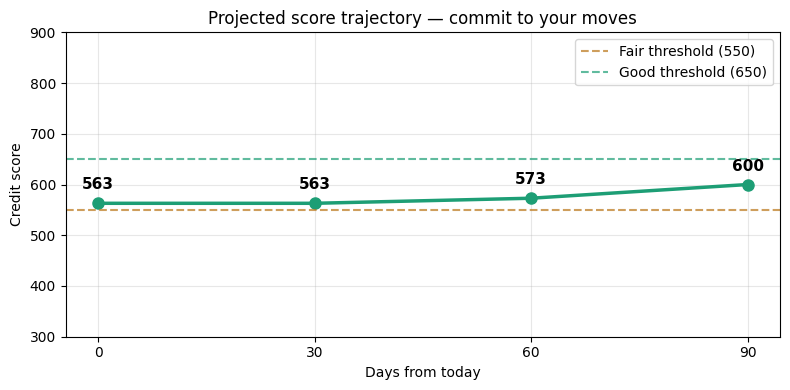

In [23]:
def project_trajectory(user: pd.DataFrame, model, days: list = [0, 30, 60, 90]) -> dict:
    """
    Project credit score over time assuming user takes all recommended moves.
    Applies moves gradually based on their timeline.
    """
    base_prob  = model.predict_proba(user)[0, 1]
    base_score = probability_to_score(base_prob)['score']
    moves = generate_moves(user, model, n_moves=5)

    trajectory = {}
    for day in days:
        modified = user.copy()
        for move in moves:
            if move['timeline_days'] <= day:
                modified[move['feature']] = move['new_val']

        prob  = model.predict_proba(modified)[0, 1]
        score = probability_to_score(prob)
        trajectory[day] = {
            'score': score['score'],
            'tier':  score['tier'],
            'moves_applied': sum(
                1 for m in moves if m['timeline_days'] <= day
            )
        }

    return trajectory

# ── Demo trajectory ───────────────────────────────────────────────────
if rejected_mask.sum() > 0:
    traj = project_trajectory(rejected_user, model_full)

    print('Score trajectory (if user commits to all moves):')
    print(f'{"Day":>6} | {"Score":>6} | {"Tier":>10} | {"Moves applied":>14}')
    print('-' * 46)
    for day, info in traj.items():
        print(f'{day:>6} | {info["score"]:>6} | {info["tier"]:>10} | {info["moves_applied"]:>14}')

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    days_list  = list(traj.keys())
    scores_list = [traj[d]['score'] for d in days_list]

    ax.plot(days_list, scores_list, 'o-', color='#1D9E75',
            linewidth=2.5, markersize=8)
    ax.axhline(550, color='#BA7517', linestyle='--', alpha=0.7, label='Fair threshold (550)')
    ax.axhline(650, color='#1D9E75', linestyle='--', alpha=0.7, label='Good threshold (650)')

    for day, score in zip(days_list, scores_list):
        ax.annotate(str(score), (day, score),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=11, fontweight='bold')

    ax.set_xlabel('Days from today')
    ax.set_ylabel('Credit score')
    ax.set_title('Projected score trajectory — commit to your moves')
    ax.legend()
    ax.set_ylim(300, 900)
    ax.set_xticks(days_list)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('./artifacts/score_trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()

## Cell 17 — Fairness audit (AIF360)

Shows the lender (B2B buyer) that the model doesn't discriminate by gender or income group. This is the regulatory compliance feature that makes NBFCs willing to integrate.

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


FAIRNESS AUDIT — Gender
Disparate Impact:              0.7038
  (> 0.8 is considered fair)
Statistical Parity Difference: -0.2213
  (close to 0 is fair)
Equal Opportunity Difference:  -0.2101
  (close to 0 is fair)

RESULT: Model shows potential gender bias — review features

Fairness metrics saved to ./artifacts/fairness_metrics.json

Approval rate by income band:
income_band
Low        0.655
Mid-low    0.645
Mid-high   0.649
High       0.740


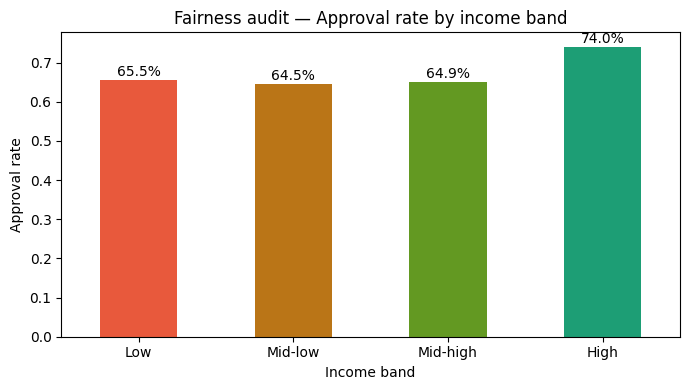

In [24]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric

# ── Prepare AIF360 dataset ────────────────────────────────────────────
# Protected attribute: gender (0=Male, 1=Female after encoding)
audit_df = X_test.copy()
audit_df['TARGET'] = y_test.values
audit_df['PREDICTED'] = model_full.predict(X_test)

# Only run if CODE_GENDER is present and has both values
if 'CODE_GENDER' in audit_df.columns and audit_df['CODE_GENDER'].nunique() > 1:

    # AIF360 needs predicted dataset too
    aif_dataset_true = BinaryLabelDataset(
        df                = audit_df[['CODE_GENDER', 'TARGET']].rename(
                               columns={'TARGET': 'label'}),
        label_names       = ['label'],
        protected_attribute_names = ['CODE_GENDER'],
        favorable_label   = 0,   # 0 = repaid = good
        unfavorable_label = 1    # 1 = default = bad
    )

    aif_dataset_pred = BinaryLabelDataset(
        df                = audit_df[['CODE_GENDER', 'PREDICTED']].rename(
                               columns={'PREDICTED': 'label'}),
        label_names       = ['label'],
        protected_attribute_names = ['CODE_GENDER'],
        favorable_label   = 0,
        unfavorable_label = 1
    )

    # Gender code varies by encoding — find which value is more common
    gender_vals = sorted(audit_df['CODE_GENDER'].unique())
    privileged_groups   = [{'CODE_GENDER': gender_vals[0]}]
    unprivileged_groups = [{'CODE_GENDER': gender_vals[1]}]

    metric = ClassificationMetric(
        aif_dataset_true, aif_dataset_pred,
        unprivileged_groups = unprivileged_groups,
        privileged_groups   = privileged_groups
    )

    disparate_impact     = metric.disparate_impact()
    stat_parity_diff     = metric.statistical_parity_difference()
    equal_opport_diff    = metric.equal_opportunity_difference()

    print('=' * 50)
    print('FAIRNESS AUDIT — Gender')
    print('=' * 50)
    print(f'Disparate Impact:              {disparate_impact:.4f}')
    print(f'  (> 0.8 is considered fair)')
    print(f'Statistical Parity Difference: {stat_parity_diff:.4f}')
    print(f'  (close to 0 is fair)')
    print(f'Equal Opportunity Difference:  {equal_opport_diff:.4f}')
    print(f'  (close to 0 is fair)')
    print()

    if disparate_impact >= 0.8:
        print('RESULT: Model passes disparate impact test (DI >= 0.8)')
    else:
        print('RESULT: Model shows potential gender bias — review features')

    # Save fairness metrics for API
    fairness_metrics = {
        'disparate_impact':          round(disparate_impact, 4),
        'statistical_parity_diff':   round(stat_parity_diff, 4),
        'equal_opportunity_diff':    round(equal_opport_diff, 4),
        'fair':                      bool(disparate_impact >= 0.8)
    }
    with open('./artifacts/fairness_metrics.json', 'w') as f:
        json.dump(fairness_metrics, f, indent=2)
    print('\nFairness metrics saved to ./artifacts/fairness_metrics.json')

else:
    print('CODE_GENDER not available for fairness audit in this split')

# ── Approval rate breakdown by income band ────────────────────────────
income_bands = pd.qcut(X_test['AMT_INCOME_TOTAL'], q=4,
                        labels=['Low', 'Mid-low', 'Mid-high', 'High'])
approval_by_income = pd.DataFrame({
    'income_band':   income_bands,
    'approved':      (model_full.predict(X_test) == 0)
}).groupby('income_band', observed=True)['approved'].mean()

print('\nApproval rate by income band:')
print(approval_by_income.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
approval_by_income.plot(kind='bar', ax=ax,
                        color=['#E8593C', '#BA7517', '#639922', '#1D9E75'])
ax.set_ylabel('Approval rate')
ax.set_xlabel('Income band')
ax.set_title('Fairness audit — Approval rate by income band')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(approval_by_income):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('./artifacts/fairness_income_bands.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 18 — Inference function (powers the FastAPI)

This is the single function your API calls. Input: raw user profile dict. Output: complete scoring response.

In [25]:
def score_user_complete(user_input: dict) -> dict:
    """
    End-to-end scoring pipeline for a single user.
    Accepts raw form inputs, returns complete scoring response.

    Input dict keys (all collectable from a form):
      income, employment_type, employment_years, age, gender,
      education, family_status, n_children, n_family,
      owns_car, owns_realty, housing_type,
      loan_amount, monthly_emi, occupation, organization
    """
    # ── 1. Map form inputs to model features ──────────────────────────
    income           = float(user_input.get('income', 150000))
    employment_years = float(user_input.get('employment_years', 2))
    age              = float(user_input.get('age', 30))
    n_children       = int(user_input.get('n_children', 0))
    n_family         = int(user_input.get('n_family', 2))
    owns_car         = int(user_input.get('owns_car', 0))
    owns_realty      = int(user_input.get('owns_realty', 0))
    loan_amount      = float(user_input.get('loan_amount', 200000))
    monthly_emi      = float(user_input.get('monthly_emi', 10000))

    # ── 2. Build feature row matching training schema ──────────────────
    # Load encoders
    le_dict = joblib.load('./artifacts/label_encoders.pkl')
    imp = joblib.load('./artifacts/imputer.pkl')

    def safe_encode(encoder, value, default=0):
        try:
            return encoder.transform([str(value)])[0]
        except:
            return default

    feature_row = {
        'CODE_GENDER':               safe_encode(le_dict['CODE_GENDER'],
                                         user_input.get('gender', 'M')),
        'CNT_CHILDREN':              n_children,
        'CNT_FAM_MEMBERS':           n_family,
        'NAME_EDUCATION_TYPE':       safe_encode(le_dict['NAME_EDUCATION_TYPE'],
                                         user_input.get('education', 'Secondary')),
        'NAME_FAMILY_STATUS':        safe_encode(le_dict['NAME_FAMILY_STATUS'],
                                         user_input.get('family_status', 'Single')),
        'NAME_INCOME_TYPE':          safe_encode(le_dict['NAME_INCOME_TYPE'],
                                         user_input.get('employment_type', 'Working')),
        'OCCUPATION_TYPE':           safe_encode(le_dict['OCCUPATION_TYPE'],
                                         user_input.get('occupation', 'Unknown')),
        'ORGANIZATION_TYPE':         safe_encode(le_dict['ORGANIZATION_TYPE'],
                                         user_input.get('organization', 'Unknown')),
        'FLAG_OWN_CAR':              owns_car,
        'FLAG_OWN_REALTY':           owns_realty,
        'NAME_HOUSING_TYPE':         safe_encode(le_dict['NAME_HOUSING_TYPE'],
                                         user_input.get('housing_type', 'Rented')),
        'AMT_INCOME_TOTAL':          income,
        'AMT_CREDIT':                loan_amount,
        'AMT_ANNUITY':               monthly_emi,
        'AMT_GOODS_PRICE':           loan_amount * 0.9,
        'NAME_CONTRACT_TYPE':        safe_encode(le_dict['NAME_CONTRACT_TYPE'], 'Cash loans'),
        'REGION_POPULATION_RELATIVE': 0.035,  # median value
        'REGION_RATING_CLIENT':       2,
        'REGION_RATING_CLIENT_W_CITY': 2,
        'FLAG_DOCUMENT_3':            int(user_input.get('has_doc_3', 1)),
        'FLAG_DOCUMENT_5':            0,
        'FLAG_DOCUMENT_6':            0,
        'FLAG_DOCUMENT_8':            0,
        'FLAG_MOBIL':                 1,
        'FLAG_EMAIL':                 int(user_input.get('has_email', 0)),
        'FLAG_PHONE':                 int(user_input.get('has_phone', 1)),
        'FLAG_WORK_PHONE':            int(user_input.get('has_work_phone', 0)),
        'AGE_YEARS':                  age,
        'EMPLOYMENT_YEARS':           employment_years,
        # Engineered
        'CREDIT_INCOME_RATIO':        loan_amount / (income + 1),
        'ANNUITY_INCOME_RATIO':       monthly_emi / ((income / 12) + 1),
        'EMPLOYMENT_AGE_RATIO':       employment_years / (age + 1),
        'INCOME_PER_PERSON':          income / (n_family + 1),
        'CREDIT_TERM':                monthly_emi / (loan_amount + 1),
        'DOWN_PAYMENT_RATIO':         (loan_amount - loan_amount * 0.9) / (loan_amount * 0.9 + 1),
        'ASSET_SCORE':                owns_car + owns_realty,
        'CHILDREN_INCOME_RATIO':      n_children / ((income / 12) + 1),
    }

    # ── 3. Align with training feature order ───────────────────────────
    with open('./artifacts/feature_cols.json') as f:
        feature_cols = json.load(f)

    user_df = pd.DataFrame([feature_row])
    for col in feature_cols:
        if col not in user_df.columns:
            user_df[col] = 0
    user_df = user_df[feature_cols]

    # ── 4. Impute ──────────────────────────────────────────────────────
    user_imputed = pd.DataFrame(
        imp.transform(user_df),
        columns=feature_cols
    )

    # ── 5. Score ───────────────────────────────────────────────────────
    model = joblib.load('./artifacts/model_full.pkl')
    prob  = model.predict_proba(user_imputed)[0, 1]
    score_result = probability_to_score(prob)

    # ── 6. SHAP explanation ────────────────────────────────────────────
    expl = joblib.load('./artifacts/shap_explainer.pkl')
    explanation = explain_user(user_imputed.iloc[0], expl)

    # ── 7. Moves ───────────────────────────────────────────────────────
    moves = generate_moves(user_imputed, model, n_moves=3)

    # ── 8. Trajectory ──────────────────────────────────────────────────
    trajectory = project_trajectory(user_imputed, model)

    return {
        'score':              score_result['score'],
        'tier':               score_result['tier'],
        'default_probability': score_result['default_probability'],
        'approval_probability': score_result['approval_probability'],
        'loan_eligible':       score_result['loan_eligible'],
        'top_factors_hurting': explanation['hurting_score'][:3],
        'top_factors_helping': explanation['helping_score'][:3],
        'moves':               moves,
        'trajectory':          trajectory,
    }

# ── Test the complete pipeline ────────────────────────────────────────
test_user = {
    'income':           180000,    # ₹15,000/month
    'employment_type':  'Working',
    'employment_years': 1.5,
    'age':              26,
    'gender':           'M',
    'education':        'Secondary / secondary special',
    'family_status':    'Single / not married',
    'n_children':       0,
    'n_family':         1,
    'owns_car':         0,
    'owns_realty':      0,
    'housing_type':     'Rented apartment',
    'loan_amount':      200000,    # ₹2 lakh
    'monthly_emi':      8000,
    'occupation':       'Laborers',
    'organization':     'Business Entity Type 3',
    'has_email':        0,
    'has_phone':        1,
}

result = score_user_complete(test_user)

print('=' * 60)
print(f'CREDIT SCORE:  {result["score"]}  ({result["tier"]})')
print(f'LOAN ELIGIBLE: {result["loan_eligible"]}')
print(f'DEFAULT PROB:  {result["default_probability"]:.1%}')
print('=' * 60)
print('\nTop factors hurting your score:')
for f in result['top_factors_hurting']:
    print(f'  - {f["feature"]}: SHAP +{f["shap"]:.4f}')
print('\nRecommended moves:')
for m in result['moves']:
    print(f'  + {m["advice"]}  →  +{m["score_delta"]} pts  ({m["effort"]} effort)')
print('\nScore trajectory:')
for day, info in result['trajectory'].items():
    print(f'  Day {day:>3}: {info["score"]}  ({info["tier"]})')

CREDIT SCORE:  601  (Fair)
LOAN ELIGIBLE: True
DEFAULT PROB:  49.6%

Top factors hurting your score:
  - EMPLOYMENT_YEARS: SHAP +0.1777
  - CODE_GENDER: SHAP +0.1117
  - NAME_EDUCATION_TYPE: SHAP +0.0919

Recommended moves:
  + Maintain your current employment for {delta:.0f} more months  →  +2 pts  (low effort)
  + Apply for a smaller loan amount (reduce by {delta_pct:.0f}%)  →  +1 pts  (low effort)

Score trajectory:
  Day   0: 602  (Fair)
  Day  30: 602  (Fair)
  Day  60: 602  (Fair)
  Day  90: 604  (Fair)


## Cell 19 — Demo personas

Three pre-built personas for the live demo. Each tells a different story.

In [26]:
DEMO_PERSONAS = {
    'ravi': {
        'name':             'Ravi — Swiggy delivery partner',
        'income':           216000,   # ₹18k/month
        'employment_type':  'Working',
        'employment_years': 0.8,      # less than a year
        'age':              24,
        'gender':           'M',
        'education':        'Secondary / secondary special',
        'family_status':    'Single / not married',
        'n_children':       0,
        'n_family':         1,
        'owns_car':         0,
        'owns_realty':      0,
        'housing_type':     'Rented apartment',
        'loan_amount':      150000,
        'monthly_emi':      7000,
        'occupation':       'Drivers',
        'organization':     'Transport: type 3',
        'has_email':        0,
        'has_phone':        1,
        'story':            'Gig worker, no CIBIL score, needs loan for bike repair'
    },
    'priya': {
        'name':             'Priya — homemaker, secondary income',
        'income':           120000,   # ₹10k/month from tuitions
        'employment_type':  'Commercial associate',
        'employment_years': 3,
        'age':              34,
        'gender':           'F',
        'education':        'Higher education',
        'family_status':    'Married',
        'n_children':       2,
        'n_family':         4,
        'owns_car':         0,
        'owns_realty':      1,       # husband owns property
        'housing_type':     'House / apartment',
        'loan_amount':      100000,
        'monthly_emi':      5000,
        'occupation':       'Unknown',
        'organization':     'Unknown',
        'has_email':        1,
        'has_phone':        1,
        'story':            'Homemaker with property collateral but no formal employment'
    },
    'deepa': {
        'name':             'Deepa — freelance graphic designer',
        'income':           360000,   # ₹30k/month variable
        'employment_type':  'Commercial associate',
        'employment_years': 2.5,
        'age':              28,
        'gender':           'F',
        'education':        'Higher education',
        'family_status':    'Single / not married',
        'n_children':       0,
        'n_family':         1,
        'owns_car':         0,
        'owns_realty':      0,
        'housing_type':     'Rented apartment',
        'loan_amount':      300000,
        'monthly_emi':      12000,
        'occupation':       'Unknown',
        'organization':     'Unknown',
        'has_email':        1,
        'has_phone':        1,
        'story':            'Freelancer with decent income but irregular cash flows'
    }
}

print('Demo persona scores:')
print('=' * 60)

persona_results = {}
for key, persona in DEMO_PERSONAS.items():
    result = score_user_complete(persona)
    persona_results[key] = result

    print(f'\n{persona["name"]}')
    print(f'Story: {persona["story"]}')
    print(f'Score: {result["score"]}  ({result["tier"]})')
    print(f'Eligible: {result["loan_eligible"]} | Default prob: {result["default_probability"]:.1%}')
    print(f'Top move: {result["moves"][0]["advice"]} → +{result["moves"][0]["score_delta"]} pts')
    print('-' * 40)

# Save persona results for frontend demo
with open('./artifacts/demo_personas.json', 'w') as f:
    json.dump(persona_results, f, indent=2, default=str)
print('\nSaved persona results to ./artifacts/demo_personas.json')

Demo persona scores:

Ravi — Swiggy delivery partner
Story: Gig worker, no CIBIL score, needs loan for bike repair
Score: 539  (Poor)
Eligible: False | Default prob: 69.2%
Top move: Apply for a smaller loan amount (reduce by {delta_pct:.0f}%) → +17 pts
----------------------------------------

Priya — homemaker, secondary income
Story: Homemaker with property collateral but no formal employment
Score: 665  (Good)
Eligible: True | Default prob: 29.3%
Top move: Apply for a smaller loan amount (reduce by {delta_pct:.0f}%) → +18 pts
----------------------------------------

Deepa — freelance graphic designer
Story: Freelancer with decent income but irregular cash flows
Score: 628  (Fair)
Eligible: True | Default prob: 40.6%
Top move: Apply for a smaller loan amount (reduce by {delta_pct:.0f}%) → +4 pts
----------------------------------------

Saved persona results to ./artifacts/demo_personas.json


## Cell 20 — Export everything for FastAPI

In [27]:
import os

artifacts = [
    './artifacts/model_full.pkl',
    './artifacts/model_thin.pkl',
    './artifacts/shap_explainer.pkl',
    './artifacts/label_encoders.pkl',
    './artifacts/imputer.pkl',
    './artifacts/feature_cols.json',
    './artifacts/fairness_metrics.json',
    './artifacts/demo_personas.json',
    './artifacts/shap_importance.csv',
]

print('Artifact export summary:')
print('=' * 50)
all_good = True
for path in artifacts:
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path)/1024:.1f} KB' if exists else 'MISSING'
    status = 'OK' if exists else 'MISSING'
    print(f'  {status:>7}  {path:45} {size}')
    if not exists:
        all_good = False

print()
if all_good:
    print('All artifacts ready. Copy ./artifacts/ to your FastAPI project.')
    print()
    print('FastAPI usage:')
    print('  POST /v1/score          → score_user_complete(user_input)')
    print('  POST /v1/counterfactual → generate_moves(user_df, model)')
    print('  GET  /v1/fairness       → load fairness_metrics.json')
    print('  GET  /v1/passport/:id   → load demo_personas.json[id]')
else:
    print('Some artifacts missing — re-run cells above.')

Artifact export summary:
       OK  ./artifacts/model_full.pkl                    1166.7 KB
       OK  ./artifacts/model_thin.pkl                    1166.7 KB
       OK  ./artifacts/shap_explainer.pkl                3537.2 KB
       OK  ./artifacts/label_encoders.pkl                3.6 KB
       OK  ./artifacts/imputer.pkl                       1.7 KB
       OK  ./artifacts/feature_cols.json                 0.7 KB
       OK  ./artifacts/fairness_metrics.json             0.1 KB
       OK  ./artifacts/demo_personas.json                6.1 KB
       OK  ./artifacts/shap_importance.csv               1.0 KB

All artifacts ready. Copy ./artifacts/ to your FastAPI project.

FastAPI usage:
  POST /v1/score          → score_user_complete(user_input)
  POST /v1/counterfactual → generate_moves(user_df, model)
  GET  /v1/fairness       → load fairness_metrics.json
  GET  /v1/passport/:id   → load demo_personas.json[id]


---
## Notebook complete

**What you have:**
- `model_full.pkl` — XGBoost trained on alternative data only (no EXT_SOURCE)
- `model_thin.pkl` — XGBoost trained on thin-file subset only  
- `shap_explainer.pkl` — per-user SHAP explanations
- `label_encoders.pkl` + `imputer.pkl` — inference preprocessing
- `feature_cols.json` — exact feature order for inference
- `fairness_metrics.json` — AIF360 audit results
- `demo_personas.json` — 3 ready demo users with scores + moves
- `score_user_complete()` — single function your FastAPI calls

**What the model deliberately does NOT use:**
- EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 (pre-computed bureau scores)
- installments_payments (only available for existing borrowers)
- bureau_balance, POS_CASH, credit_card_balance

**The pitch line:** *"We scored 450 million invisible Indians using only the data they already have — no bureau score required."*